### 푸리에 변환

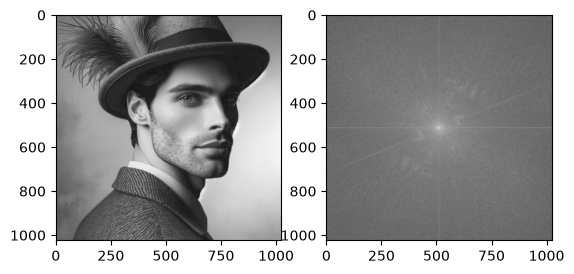

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

##1. 이미지로드
img = cv2.imread('../fff/like_lenna.png',cv2.IMREAD_GRAYSCALE)

## 2. 푸리에 변환 적용
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
spectruum = 20 * np.log(np.abs(fshift))

## 3. 주파수 시각화
plt.subplot(121)
plt.imshow(img, cmap='gray')

plt.subplot(122)
plt.imshow(spectruum, cmap='gray')

plt.show()

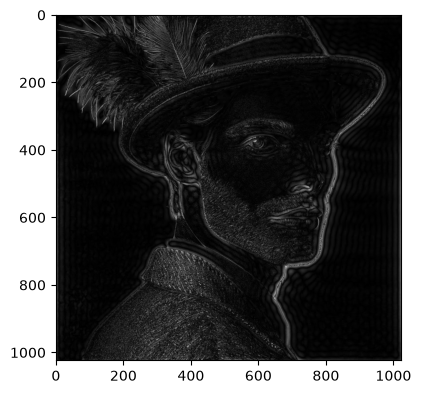

In [15]:
## 고주파 제거
rows, cols = img.shape
crow, ccol = rows//2, cols//2
rr = 30
mask = np.ones((rows,cols),np.uint8)
#mask
mask[crow-rr:crow+rr, ccol-rr:ccol+rr] = 0
#np.savetxt("../fff/aaa.txt", mask, fmt="%d")
fshift_filter = fshift*mask ## 0을 곱하여 0으로 변경

## 역 푸리에 변환
f_ishift = np.fft.ifftshift(fshift_filter)
img_back= np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

## 시각화
plt.figure(figsize=(12,12))
plt.subplot(133)
plt.imshow(img_back,cmap="gray")
plt.tight_layout()
plt.show()


이미지 경계 검출

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

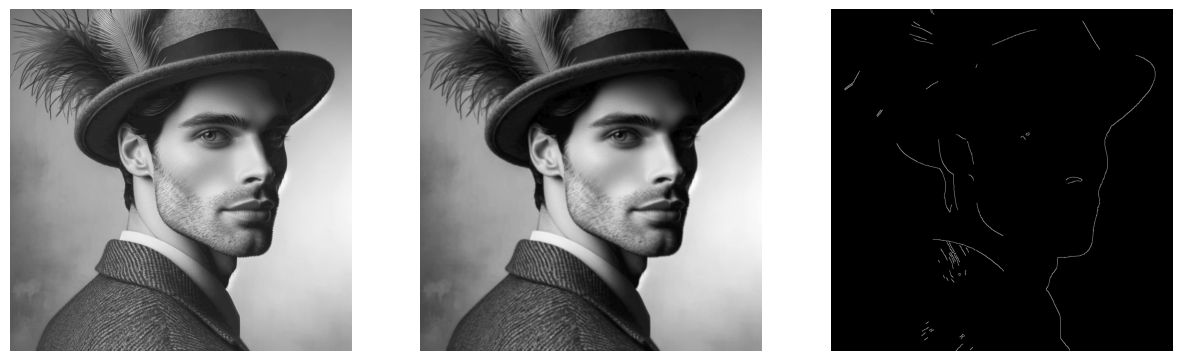

In [22]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('../fff/like_lenna.png', cv2.IMREAD_GRAYSCALE)

## 가우시안 블러
blur_img = cv2.GaussianBlur(img,(5,5),1.4)

## 캐니 애지 검출
canny_edges = cv2.Canny(blur_img, threshold1=150, threshold2=250)

fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(img,cmap='gray')
axes[1].imshow(blur_img,cmap='gray')
axes[2].imshow(canny_edges,cmap='gray')

axes[0].axis('off')
axes[1].axis('off')
axes[2].axis('off')